In [1]:
#install required data
#!pip install hecdss --break-system-packages

In [2]:
#import required data
import pandas as pd
#from hecdss import HecDss
from datetime import datetime
from pydsstools.core import TimeSeriesContainer, UNDEFINED
from pydsstools.heclib.dss import HecDss

In [3]:
#open the observed data, select sheet and clip columns
dfRaw = pd.read_csv('../l1processedData/Xls/flowMiamiRiver_s0013_nc03_no028.csv')
#dfRaw = dfRaw[['SW2','flowm3s']]
dfRaw.head()

,SW2,ElevRaw,waterStage,flowm3s
0,2023-01-01 00:00:00,145.262786,148.662786,81.452585
1,2023-01-01 01:00:00,145.273004,148.673004,82.446497
2,2023-01-01 02:00:00,145.292494,148.692494,84.295075
3,2023-01-01 03:00:00,145.302354,148.702354,85.274388
4,2023-01-01 04:00:00,145.318458,148.718458,86.817943


In [4]:
dfRaw.tail()

,SW2,ElevRaw,waterStage,flowm3s
1435,2023-03-01 19:00:00,146.202409,149.602409,205.001274
1436,2023-03-01 20:00:00,146.188216,149.588216,201.805860
1437,2023-03-01 21:00:00,146.185936,149.585936,201.296412
1438,2023-03-01 22:00:00,146.179716,149.579716,199.911699
1439,2023-03-01 23:00:00,146.147194,149.547194,193.547122


In [5]:
#import data on a correct format
dfHeads = pd.DataFrame()
dfHeads.index=pd.to_datetime(dfRaw['SW2'])
dfHeads['Flow m3/s'] = pd.to_numeric(dfRaw['flowm3s']).to_list()
dfHeads['Factor'] = 0.98
dfHeads['Flow m3/s x Factor'] = dfHeads['Flow m3/s'] * dfHeads['Factor']
dfHeads.head()

,Flow m3/s,Factor,Flow m3/s x Factor
SW2,,,
2023-01-01 00:00:00,81.452585,0.98,79.823533
2023-01-01 01:00:00,82.446497,0.98,80.797568
2023-01-01 02:00:00,84.295075,0.98,82.609174
2023-01-01 03:00:00,85.274388,0.98,83.568901
2023-01-01 04:00:00,86.817943,0.98,85.081584


<AxesSubplot: xlabel='SW2'>

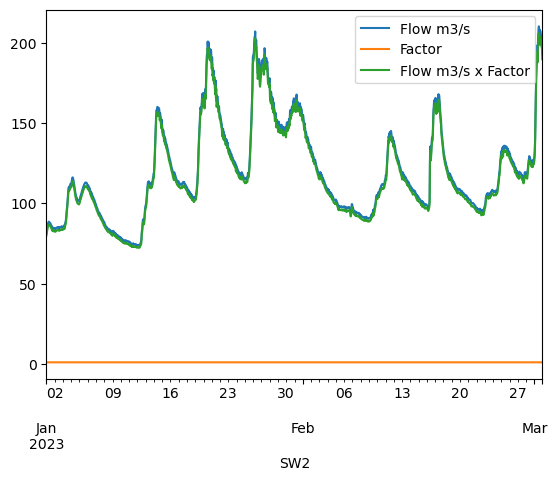

In [6]:
#plot histogram
dfHeads.plot()

In [7]:
# 2. Extract arrays
times = dfHeads.index.tolist()
#values = dfHeads['Flow m3/s'].astype(float).tolist()
values = dfHeads['Flow m3/s x Factor'].astype(float).tolist()

dss_file = "../l1processedData/Xls/riverFlowSw2_s00013_nc03_no028_f98.dss"
pathname = "/THEISNASH/SW1/FLOW//1HOUR/OBSERVED/"

with HecDss.Open(dss_file) as fid:
    count = len(values)
    interval = 1  # positive = regular time series

    tsc = TimeSeriesContainer(pathname, count, interval)
    tsc.start_time = times[0]
    tsc.data_units = "CMS"
    tsc.data_type = "INST-VAL"
    tsc.tzid = "UTC"
    tsc.values = values  # UNDEFINED marks missing data

    fid.put_ts(tsc)

20:14:09.418      -----DSS---zopen   Existing file opened,  File: /mnt/c/Users/saulm/Documents/GitHub/theisNashEnvironmentalMonitoringModelingSite/l1processedData/Xls/riverFlowSw2_s00013_nc03_no028_f98.dss
20:14:09.418                         Handle 71;  Process: 54959;  DSS Versions - Software: 7-IV, File:  7-IV
20:14:09.419                         Single-user advisory access mode
20:14:09.435 -----DSS--- zwrite  Handle 71;  Version 2:  /THEISNASH/SW1/FLOW/01Dec2022/1Hour/OBSERVED/
20:14:09.442 -----DSS--- zwrite  Handle 71;  Version 2:  /THEISNASH/SW1/FLOW/01Jan2023/1Hour/OBSERVED/
20:14:09.450 -----DSS--- zwrite  Handle 71;  Version 2:  /THEISNASH/SW1/FLOW/01Feb2023/1Hour/OBSERVED/
20:14:09.458 -----DSS--- zwrite  Handle 71;  Version 2:  /THEISNASH/SW1/FLOW/01Mar2023/1Hour/OBSERVED/
20:14:09.463      -----DSS---zclose  Handle 71;  Process: 54959;  File: /mnt/c/Users/saulm/Documents/GitHub/theisNashEnvironmentalMonitoringModelingSite/l1processedData/Xls/riverFlowSw2_s00013_nc03_no028